# Fusion Embeddings (TF-IDF + PhoBERT v2 Layer 12)

**Workflow**: Generate embeddings (TF-IDF 900 dim + PhoBERT Layer 12) → Test TF-IDF alone → Fusion (concatenate vectors) → LogReg evaluation

**Strategy**:
1. Load text data (TF-IDF uses strict text, PhoBERT uses loose text)
2. **Generate TF-IDF embeddings** (900 dim on strict text)
3. **Generate PhoBERT embeddings from encoder output (Layer 12)** (both pretrained & finetuned from loose text)
4. **STEP 1**: Verify TF-IDF 900 dim alone with LogReg
5. **STEP 2**: Fuse embeddings (concatenate vectors)
6. Train LogReg on fused embeddings
7. Compare all methods

## 1. Import Libraries

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 2. Load Train/Val Data

In [21]:
# Load train, validation sets
train_path = '../../data/splited/train_set.csv'
val_path = '../../data/splited/val_set.csv'

df_train = pd.read_csv(train_path)
df_val = pd.read_csv(val_path)

labels_train = df_train['label'].values
labels_val = df_val['label'].values

print("="*80)
print("DATA LOADED")
print("="*80)
print(f"\nTrain set: {df_train.shape[0]} samples, Labels: {(labels_train == 0).sum()} fake / {(labels_train == 1).sum()} real")
print(f"Val set: {df_val.shape[0]} samples, Labels: {(labels_val == 0).sum()} fake / {(labels_val == 1).sum()} real")

DATA LOADED

Train set: 3788 samples, Labels: 3143 fake / 645 real
Val set: 474 samples, Labels: 393 fake / 81 real


## 3. Generate TF-IDF Embeddings (900 dim)

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

print("\n" + "="*80)
print("GENERATING TF-IDF EMBEDDINGS (900 DIM)")
print("="*80)

# Get text data (use strict text for TF-IDF)
texts_train_strict = df_train['text_strict'].fillna('').tolist()
texts_val_strict = df_val['text_strict'].fillna('').tolist()

print(f"\nTrain texts: {len(texts_train_strict)}")
print(f"Val texts: {len(texts_val_strict)}")

# Step 1: Create FULL TF-IDF vectorizer (same as n0)
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_df=0.95,
    min_df=2,
    sublinear_tf=True
)

# Fit on train, transform both
X_train_tfidf_full = tfidf.fit_transform(texts_train_strict)
X_val_tfidf_full = tfidf.transform(texts_val_strict)

print(f"\nFull TF-IDF vocabulary size: {X_train_tfidf_full.shape[1]}")
print(f"Train shape (full): {X_train_tfidf_full.shape}")
print(f"Val shape (full): {X_val_tfidf_full.shape}")

# Step 2: Apply TruncatedSVD to reduce to 900 dims (same aa n0)
svd = TruncatedSVD(n_components=900, random_state=42)
X_train_tfidf = svd.fit_transform(X_train_tfidf_full)
X_val_tfidf = svd.transform(X_val_tfidf_full)

explained_var = svd.explained_variance_ratio_.sum()

print(f"\n✅ TF-IDF embeddings generated (with SVD reduction):")
print(f"   Train: {X_train_tfidf.shape}")
print(f"   Val: {X_val_tfidf.shape}")
print(f"   Variance retained: {explained_var:.2%}")


GENERATING TF-IDF EMBEDDINGS (900 DIM)

Train texts: 3788
Val texts: 474

Full TF-IDF vocabulary size: 57103
Train shape (full): (3788, 57103)
Val shape (full): (474, 57103)

✅ TF-IDF embeddings generated (with SVD reduction):
   Train: (3788, 900)
   Val: (474, 900)
   Variance retained: 49.05%


## 4. Generate PhoBERT Embeddings (768 dim)

In [23]:
import torch
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
import gc

print("\n" + "="*80)
print("GENERATING PHOBERT EMBEDDINGS (LAYER 0 & LAYER 12)")
print("="*80)

# Get text data (use loose text for PhoBERT)
texts_train_loose = df_train['text_loose'].fillna('').tolist()
texts_val_loose = df_val['text_loose'].fillna('').tolist()

def extract_embeddings_phobert_dual(texts, model_name, device='cuda', batch_size=16):
    """
    Extract [CLS] token embeddings from BOTH Layer 0 and Layer 12 of PhoBERT model.
    Returns: (embeddings_layer0, embeddings_layer12) each with shape (num_texts, 768)
    """
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device).eval()
    
    embeddings_layer0 = []
    embeddings_layer12 = []
    
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc=f"Extracting {model_name.split('/')[-1]}"):
            batch = texts[i:i+batch_size]
            
            # Tokenize
            inputs = tokenizer(batch, return_tensors='pt', padding=True, truncation=True, max_length=256)
            inputs = {k: v.to(device) for k, v in inputs.items()}
            
            # Forward pass with hidden states
            outputs = model(**inputs, output_hidden_states=True)
            
            # Layer 0: [CLS] token from embedding layer (first hidden state)
            cls_layer0 = outputs.hidden_states[0][:, 0, :].cpu().numpy()
            embeddings_layer0.extend(cls_layer0)
            
            # Layer 12: [CLS] token from encoder output (last hidden state)
            cls_layer12 = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings_layer12.extend(cls_layer12)
            
            # Clear GPU cache
            del outputs, inputs
            torch.cuda.empty_cache()
    
    # Move model back to CPU to free GPU memory
    model.to('cpu')
    del model, tokenizer
    gc.collect()
    torch.cuda.empty_cache()
    
    return np.array(embeddings_layer0), np.array(embeddings_layer12)

# PhoBERT v2 Pretrained
print("\n▶️ Extracting PhoBERT v2 Pretrained embeddings (Layer 0 & 12)...")
X_train_phobert_pretrain_l0, X_train_phobert_pretrain_l12 = extract_embeddings_phobert_dual(texts_train_loose, 'vinai/phobert-base-v2', batch_size=16)
X_val_phobert_pretrain_l0, X_val_phobert_pretrain_l12 = extract_embeddings_phobert_dual(texts_val_loose, 'vinai/phobert-base-v2', batch_size=16)
print(f"✅ PhoBERT v2 Pretrained - Layer 0: {X_train_phobert_pretrain_l0.shape}, Layer 12: {X_train_phobert_pretrain_l12.shape}")

# PhoBERT v2 Finetuned
print("\n▶️ Extracting PhoBERT v2 Finetuned embeddings (Layer 0 & 12)...")
X_train_phobert_finetuned_l0, X_train_phobert_finetuned_l12 = extract_embeddings_phobert_dual(texts_train_loose, '../../model/finetuned/PhoBERT_v2', batch_size=16)
X_val_phobert_finetuned_l0, X_val_phobert_finetuned_l12 = extract_embeddings_phobert_dual(texts_val_loose, '../../model/finetuned/PhoBERT_v2', batch_size=16)
print(f"✅ PhoBERT v2 Finetuned - Layer 0: {X_train_phobert_finetuned_l0.shape}, Layer 12: {X_train_phobert_finetuned_l12.shape}")

# 🔍 DEBUG: Check Layer 0 vs Layer 12 difference
mean_diff_l0_l12_pretrain = np.mean(np.abs(X_train_phobert_pretrain_l0 - X_train_phobert_pretrain_l12))
mean_diff_l0_l12_finetuned = np.mean(np.abs(X_train_phobert_finetuned_l0 - X_train_phobert_finetuned_l12))
print(f"\n🔍 DEBUG:")
print(f"   Mean difference Layer 0 vs Layer 12 (Pretrain): {mean_diff_l0_l12_pretrain:.6f}")
print(f"   Mean difference Layer 0 vs Layer 12 (Finetuned): {mean_diff_l0_l12_finetuned:.6f}")


GENERATING PHOBERT EMBEDDINGS (LAYER 0 & LAYER 12)

▶️ Extracting PhoBERT v2 Pretrained embeddings (Layer 0 & 12)...


Some weights of RobertaModel were not initialized from the model checkpoint at vinai/phobert-base-v2 and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Extracting phobert-base-v2: 100%|██████████| 237/237 [01:43<00:00,  2.28it/s]
Some weights of RobertaModel were not initialized from the model checkpoint at vinai/phobert-base-v2 and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Extracting phobert-base-v2: 100%|██████████| 30/30 [00:13<00:00,  2.21it/s]


✅ PhoBERT v2 Pretrained - Layer 0: (3788, 768), Layer 12: (3788, 768)

▶️ Extracting PhoBERT v2 Finetuned embeddings (Layer 0 & 12)...


Some weights of RobertaModel were not initialized from the model checkpoint at ../../model/finetuned/PhoBERT_v2 and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Extracting PhoBERT_v2: 100%|██████████| 237/237 [01:43<00:00,  2.28it/s]
Some weights of RobertaModel were not initialized from the model checkpoint at ../../model/finetuned/PhoBERT_v2 and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Extracting PhoBERT_v2: 100%|██████████| 30/30 [00:13<00:00,  2.26it/s]


✅ PhoBERT v2 Finetuned - Layer 0: (3788, 768), Layer 12: (3788, 768)

🔍 DEBUG:
   Mean difference Layer 0 vs Layer 12 (Pretrain): 0.243412
   Mean difference Layer 0 vs Layer 12 (Finetuned): 0.242886


## 4. Evaluate Functions

In [24]:
def evaluate_embeddings(X_train, y_train, X_val, y_val, method_name):
    """
    Train LogReg on embeddings and evaluate on validation set.
    """
    # Scale embeddings
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    # Train LogReg
    clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    clf.fit(X_train_scaled, y_train)
    
    # Predict on validation
    y_pred = clf.predict(X_val_scaled)
    y_pred_proba = clf.predict_proba(X_val_scaled)[:, 1]
    
    results = {
        'method': method_name,
        'accuracy': accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred, average='weighted'),
        'recall': recall_score(y_val, y_pred, average='weighted'),
        'f1': f1_score(y_val, y_pred, average='weighted'),
        'auc': roc_auc_score(y_val, y_pred_proba)
    }
    
    return results, X_train_scaled, X_val_scaled, clf

print("✅ Utility functions defined")

✅ Utility functions defined


## 6. STEP 1: Test TF-IDF 900 dim Alone (Verification)

In [25]:
print("\n" + "="*80)
print("STEP 1: TF-IDF 900 DIM VERIFICATION")
print("="*80)

print(f"\nDimension: {X_train_tfidf.shape[1]} features")
print(f"Train shape: {X_train_tfidf.shape}")
print(f"Val shape: {X_val_tfidf.shape}")

# Evaluate
results_tfidf, _, _, _ = evaluate_embeddings(
    X_train_tfidf, labels_train, X_val_tfidf, labels_val,
    "TF-IDF 900-dim (strict text)"
)

print(f"\n✅ TF-IDF Results:")
for k, v in results_tfidf.items():
    if k != 'method':
        print(f"  {k}: {v:.4f}")


STEP 1: TF-IDF 900 DIM VERIFICATION

Dimension: 900 features
Train shape: (3788, 900)
Val shape: (474, 900)

✅ TF-IDF Results:
  accuracy: 0.9051
  precision: 0.9010
  recall: 0.9051
  f1: 0.9023
  auc: 0.9004


## 7. STEP 2: Fusion Strategy - Vector Concatenation

In [26]:
print("\n" + "="*80)
print("STEP 2: EMBEDDING CONFIGURATIONS (4 ALONE + 4 FUSION)")
print("="*80)

print(f"\nDimensions:")
print(f"  TF-IDF: {X_train_tfidf.shape[1]}")
print(f"  PhoBERT Layer 0: {X_train_phobert_pretrain_l0.shape[1]}")
print(f"  PhoBERT Layer 12: {X_train_phobert_pretrain_l12.shape[1]}")

# Define all 8 configurations
configs = []

# ===== ALONE (4 loại) =====
print(f"\n{'='*80}")
print("STANDALONE EMBEDDINGS (4 loại)")
print(f"{'='*80}")

# 1. PhoBERT v2 Pretrained Layer 0
configs.append({
    'name': 'PhoBERT v2 Pretrained (Layer 0) - ALONE',
    'train': X_train_phobert_pretrain_l0,
    'val': X_val_phobert_pretrain_l0,
    'dims': X_train_phobert_pretrain_l0.shape[1]
})
print(f"1. PhoBERT v2 Pretrained Layer 0: {X_train_phobert_pretrain_l0.shape[1]} dims")

# 2. PhoBERT v2 Pretrained Layer 12
configs.append({
    'name': 'PhoBERT v2 Pretrained (Layer 12) - ALONE',
    'train': X_train_phobert_pretrain_l12,
    'val': X_val_phobert_pretrain_l12,
    'dims': X_train_phobert_pretrain_l12.shape[1]
})
print(f"2. PhoBERT v2 Pretrained Layer 12: {X_train_phobert_pretrain_l12.shape[1]} dims")

# 3. PhoBERT v2 Finetuned Layer 0
configs.append({
    'name': 'PhoBERT v2 Finetuned (Layer 0) - ALONE',
    'train': X_train_phobert_finetuned_l0,
    'val': X_val_phobert_finetuned_l0,
    'dims': X_train_phobert_finetuned_l0.shape[1]
})
print(f"3. PhoBERT v2 Finetuned Layer 0: {X_train_phobert_finetuned_l0.shape[1]} dims")

# 4. PhoBERT v2 Finetuned Layer 12
configs.append({
    'name': 'PhoBERT v2 Finetuned (Layer 12) - ALONE',
    'train': X_train_phobert_finetuned_l12,
    'val': X_val_phobert_finetuned_l12,
    'dims': X_train_phobert_finetuned_l12.shape[1]
})
print(f"4. PhoBERT v2 Finetuned Layer 12: {X_train_phobert_finetuned_l12.shape[1]} dims")

# ===== FUSION (4 loại) =====
print(f"\n{'='*80}")
print("FUSION EMBEDDINGS (TF-IDF + PhoBERT) (4 loại)")
print(f"{'='*80}")

# 5. TF-IDF + PhoBERT Pretrain Layer 0
fusion_l0_pretrain = np.hstack([X_train_tfidf, X_train_phobert_pretrain_l0])
fusion_val_l0_pretrain = np.hstack([X_val_tfidf, X_val_phobert_pretrain_l0])
configs.append({
    'name': 'TF-IDF + PhoBERT Pretrain (Layer 0)',
    'train': fusion_l0_pretrain,
    'val': fusion_val_l0_pretrain,
    'dims': fusion_l0_pretrain.shape[1]
})
print(f"5. TF-IDF + PhoBERT Pretrain Layer 0: {fusion_l0_pretrain.shape[1]} dims (900 + 768)")

# 6. TF-IDF + PhoBERT Pretrain Layer 12
fusion_l12_pretrain = np.hstack([X_train_tfidf, X_train_phobert_pretrain_l12])
fusion_val_l12_pretrain = np.hstack([X_val_tfidf, X_val_phobert_pretrain_l12])
configs.append({
    'name': 'TF-IDF + PhoBERT Pretrain (Layer 12)',
    'train': fusion_l12_pretrain,
    'val': fusion_val_l12_pretrain,
    'dims': fusion_l12_pretrain.shape[1]
})
print(f"6. TF-IDF + PhoBERT Pretrain Layer 12: {fusion_l12_pretrain.shape[1]} dims (900 + 768)")

# 7. TF-IDF + PhoBERT Finetuned Layer 0
fusion_l0_finetuned = np.hstack([X_train_tfidf, X_train_phobert_finetuned_l0])
fusion_val_l0_finetuned = np.hstack([X_val_tfidf, X_val_phobert_finetuned_l0])
configs.append({
    'name': 'TF-IDF + PhoBERT Finetuned (Layer 0)',
    'train': fusion_l0_finetuned,
    'val': fusion_val_l0_finetuned,
    'dims': fusion_l0_finetuned.shape[1]
})
print(f"7. TF-IDF + PhoBERT Finetuned Layer 0: {fusion_l0_finetuned.shape[1]} dims (900 + 768)")

# 8. TF-IDF + PhoBERT Finetuned Layer 12
fusion_l12_finetuned = np.hstack([X_train_tfidf, X_train_phobert_finetuned_l12])
fusion_val_l12_finetuned = np.hstack([X_val_tfidf, X_val_phobert_finetuned_l12])
configs.append({
    'name': 'TF-IDF + PhoBERT Finetuned (Layer 12)',
    'train': fusion_l12_finetuned,
    'val': fusion_val_l12_finetuned,
    'dims': fusion_l12_finetuned.shape[1]
})
print(f"8. TF-IDF + PhoBERT Finetuned Layer 12: {fusion_l12_finetuned.shape[1]} dims (900 + 768)")


STEP 2: EMBEDDING CONFIGURATIONS (4 ALONE + 4 FUSION)

Dimensions:
  TF-IDF: 900
  PhoBERT Layer 0: 768
  PhoBERT Layer 12: 768

STANDALONE EMBEDDINGS (4 loại)
1. PhoBERT v2 Pretrained Layer 0: 768 dims
2. PhoBERT v2 Pretrained Layer 12: 768 dims
3. PhoBERT v2 Finetuned Layer 0: 768 dims
4. PhoBERT v2 Finetuned Layer 12: 768 dims

FUSION EMBEDDINGS (TF-IDF + PhoBERT) (4 loại)
5. TF-IDF + PhoBERT Pretrain Layer 0: 1668 dims (900 + 768)
6. TF-IDF + PhoBERT Pretrain Layer 12: 1668 dims (900 + 768)
7. TF-IDF + PhoBERT Finetuned Layer 0: 1668 dims (900 + 768)
8. TF-IDF + PhoBERT Finetuned Layer 12: 1668 dims (900 + 768)


## 8. Evaluate All Methods

In [27]:
print("\n" + "="*80)
print("TRAINING & EVALUATION (9 Methods Total)")
print("="*80)

all_results = []

# Add TF-IDF baseline
print(f"\n▶️ TF-IDF 900-dim (baseline)...")
results_tfidf, _, _, _ = evaluate_embeddings(
    X_train_tfidf, labels_train, X_val_tfidf, labels_val,
    "TF-IDF 900-dim"
)
all_results.append(results_tfidf)
print(f"   ✅ F1: {results_tfidf['f1']:.4f} | AUC: {results_tfidf['auc']:.4f}")

# Evaluate all configs (4 alone + 4 fusion)
for i, config in enumerate(configs, 1):
    print(f"\n▶️ {i}. {config['name']}...")
    results, _, _, _ = evaluate_embeddings(
        config['train'], labels_train,
        config['val'], labels_val,
        config['name']
    )
    all_results.append(results)
    print(f"   ✅ F1: {results['f1']:.4f} | AUC: {results['auc']:.4f}")

# Display results table
print("\n" + "="*80)
print("COMPREHENSIVE RESULTS TABLE (9 Methods)")
print("="*80)
df_results = pd.DataFrame(all_results)
print("\n" + df_results.to_string(index=False))

# Find best method by F1
best_idx = df_results['f1'].idxmax()
best_method = df_results.loc[best_idx, 'method']
best_f1 = df_results.loc[best_idx, 'f1']
best_auc = df_results.loc[best_idx, 'auc']

print("\n" + "="*80)
print("PERFORMANCE RANKING")
print("="*80)
df_ranking = df_results[['method', 'f1', 'auc']].sort_values('f1', ascending=False).reset_index(drop=True)
df_ranking.index = df_ranking.index + 1
print("\nBy F1 Score:")
print(df_ranking.to_string())

print(f"\n⭐ BEST METHOD: {best_method}")
print(f"   F1: {best_f1:.4f} | AUC: {best_auc:.4f}")


TRAINING & EVALUATION (9 Methods Total)

▶️ TF-IDF 900-dim (baseline)...
   ✅ F1: 0.9023 | AUC: 0.9004

▶️ 1. PhoBERT v2 Pretrained (Layer 0) - ALONE...
   ✅ F1: 0.7517 | AUC: 0.5000

▶️ 2. PhoBERT v2 Pretrained (Layer 12) - ALONE...
   ✅ F1: 0.8643 | AUC: 0.8976

▶️ 3. PhoBERT v2 Finetuned (Layer 0) - ALONE...
   ✅ F1: 0.7517 | AUC: 0.5000

▶️ 4. PhoBERT v2 Finetuned (Layer 12) - ALONE...
   ✅ F1: 0.8940 | AUC: 0.8616

▶️ 5. TF-IDF + PhoBERT Pretrain (Layer 0)...
   ✅ F1: 0.9023 | AUC: 0.9004

▶️ 6. TF-IDF + PhoBERT Pretrain (Layer 12)...
   ✅ F1: 0.9091 | AUC: 0.9348

▶️ 7. TF-IDF + PhoBERT Finetuned (Layer 0)...
   ✅ F1: 0.9023 | AUC: 0.9004

▶️ 8. TF-IDF + PhoBERT Finetuned (Layer 12)...
   ✅ F1: 0.9072 | AUC: 0.8989

COMPREHENSIVE RESULTS TABLE (9 Methods)

                                  method  accuracy  precision   recall       f1      auc
                          TF-IDF 900-dim  0.905063   0.901036 0.905063 0.902260 0.900449
 PhoBERT v2 Pretrained (Layer 0) - ALONE  0.8291

## 9. Save Results

In [28]:
# Save results
output_dir = '../../data/encoded/fusion_embeddings'
os.makedirs(output_dir, exist_ok=True)

csv_path = f'{output_dir}/fusion_results.csv'
df_results.to_csv(csv_path, index=False)
print(f"✅ Results saved to: {csv_path}")
print("\n" + "="*80)
print("✅ ALL DONE!")
print("="*80)

✅ Results saved to: ../../data/encoded/fusion_embeddings/fusion_results.csv

✅ ALL DONE!



VISUALIZATION: LAYER 0 vs LAYER 12 (ALONE & FUSION)


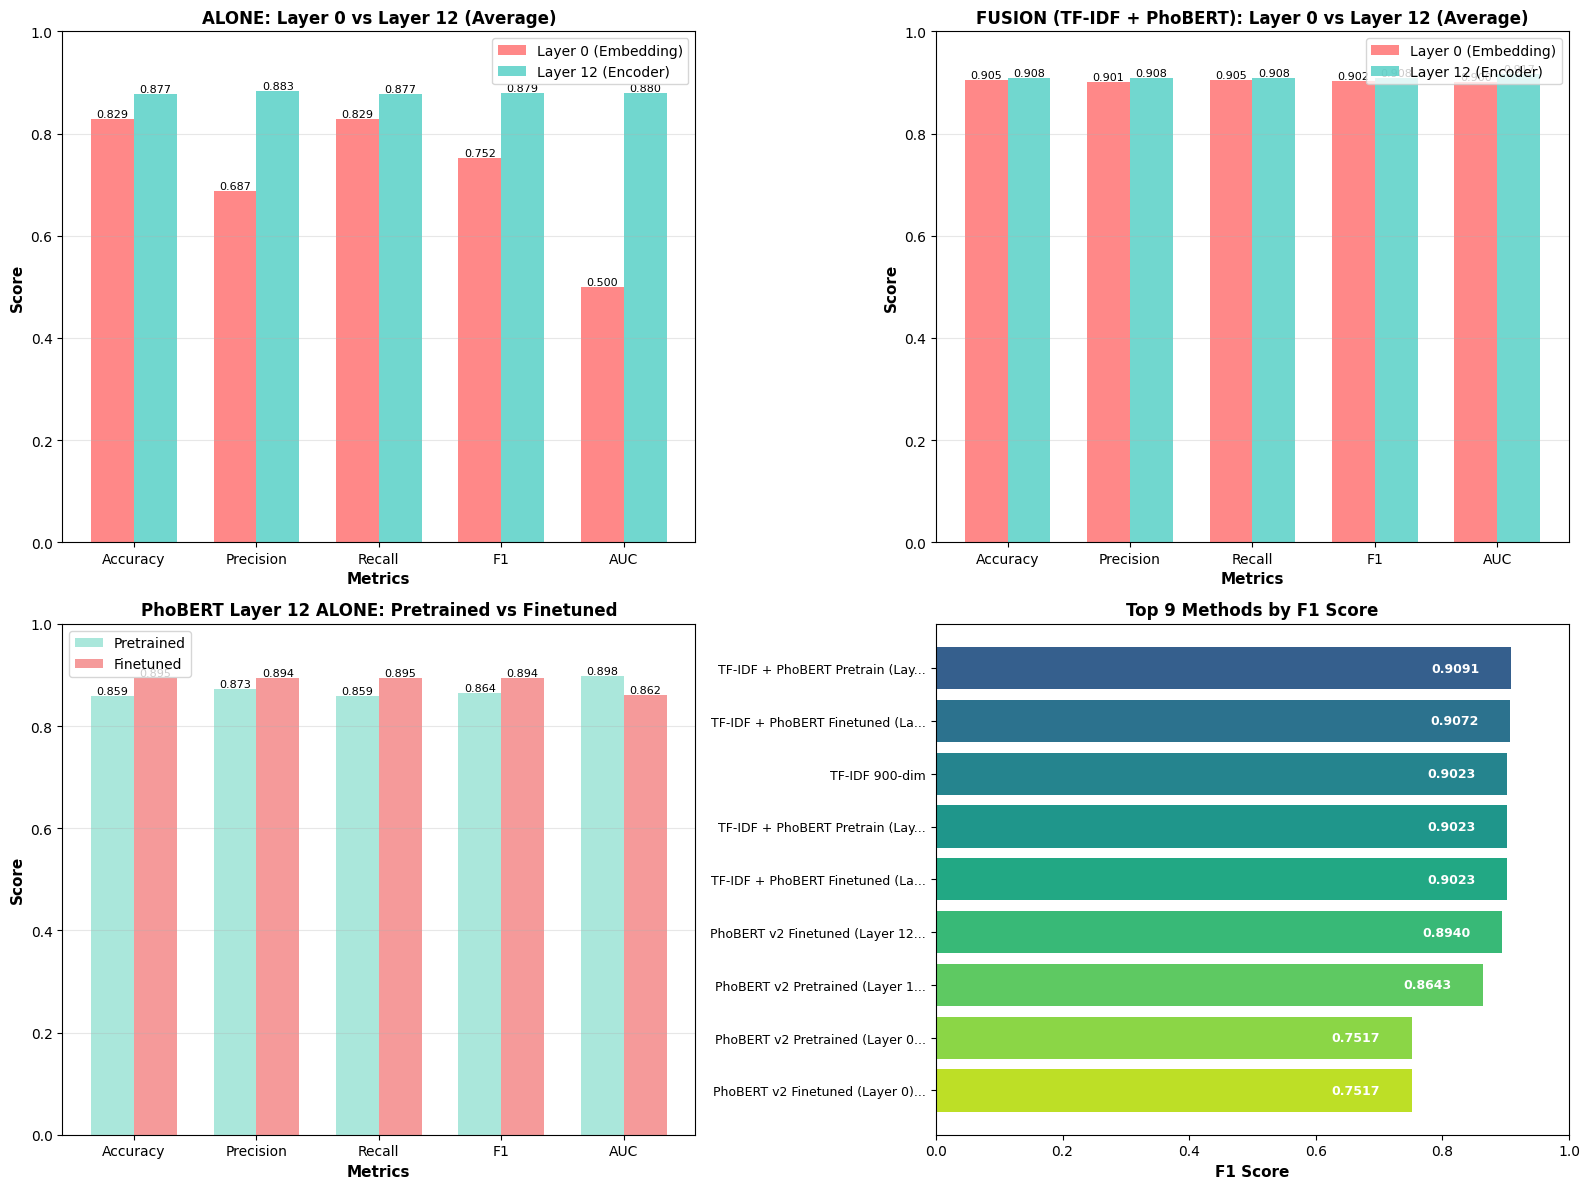

In [32]:
print("\n" + "="*80)
print("VISUALIZATION: LAYER 0 vs LAYER 12 (ALONE & FUSION)")
print("="*80)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Prepare data for visualization
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
metric_cols = ['accuracy', 'precision', 'recall', 'f1', 'auc']

# ===== CHART 1: ALONE Comparison (Layer 0 vs Layer 12) =====
ax = axes[0]
alone_results = df_results[df_results['method'].str.contains('ALONE', na=False)]
layer0_alone = alone_results[alone_results['method'].str.contains('Layer 0', na=False)]
layer12_alone = alone_results[alone_results['method'].str.contains('Layer 12', na=False)]

x = np.arange(len(metrics))
width = 0.35

# Get average scores for Layer 0 and Layer 12 (works with 1 or many rows)
if layer0_alone.empty or layer12_alone.empty:
    raise ValueError("Missing ALONE results for Layer 0 or Layer 12 in df_results.")

layer0_avg = layer0_alone[metric_cols].mean().values
layer12_avg = layer12_alone[metric_cols].mean().values

bars1 = ax.bar(x - width/2, layer0_avg, width, label='Layer 0 (Embedding)', color='#FF6B6B', alpha=0.8)
bars2 = ax.bar(x + width/2, layer12_avg, width, label='Layer 12 (Encoder)', color='#4ECDC4', alpha=0.8)

ax.set_xlabel('Metrics', fontsize=11, fontweight='bold')
ax.set_ylabel('Score', fontsize=11, fontweight='bold')
ax.set_title('ALONE: Layer 0 vs Layer 12 (Average)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim([0, 1.0])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# ===== CHART 2: FUSION Comparison (Layer 0 vs Layer 12) =====
# ===== CHART 2: FUSION Comparison (Layer 0 vs Layer 12) =====
ax = axes[1]
fusion_results = df_results[df_results['method'].str.contains('TF-IDF', na=False)]
fusion_l0 = fusion_results[fusion_results['method'].str.contains('Layer 0', na=False)]
fusion_l12 = fusion_results[fusion_results['method'].str.contains('Layer 12', na=False)]

if fusion_l0.empty or fusion_l12.empty:
    raise ValueError("Missing FUSION TF-IDF results for Layer 0 or Layer 12 in df_results.")

fusion_l0_avg = fusion_l0[metric_cols].mean().values
fusion_l12_avg = fusion_l12[metric_cols].mean().values
bars3 = ax.bar(x - width/2, fusion_l0_avg, width, label='Layer 0 (Embedding)', color='#FF6B6B', alpha=0.8)
bars4 = ax.bar(x + width/2, fusion_l12_avg, width, label='Layer 12 (Encoder)', color='#4ECDC4', alpha=0.8)

ax.set_xlabel('Metrics', fontsize=11, fontweight='bold')
ax.set_ylabel('Score', fontsize=11, fontweight='bold')
ax.set_title('FUSION (TF-IDF + PhoBERT): Layer 0 vs Layer 12 (Average)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim([0, 1.0])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# ===== CHART 3: Pretrained vs Finetuned (Layer 12 only) =====
ax = axes[2]
pretrain_l12 = df_results[df_results['method'] == 'PhoBERT v2 Pretrained (Layer 12) - ALONE']
finetuned_l12 = df_results[df_results['method'] == 'PhoBERT v2 Finetuned (Layer 12) - ALONE']

pretrain_vals = pretrain_l12[['accuracy', 'precision', 'recall', 'f1', 'auc']].values[0]
finetuned_vals = finetuned_l12[['accuracy', 'precision', 'recall', 'f1', 'auc']].values[0]

bars5 = ax.bar(x - width/2, pretrain_vals, width, label='Pretrained', color='#95E1D3', alpha=0.8)
bars6 = ax.bar(x + width/2, finetuned_vals, width, label='Finetuned', color='#F38181', alpha=0.8)

ax.set_xlabel('Metrics', fontsize=11, fontweight='bold')
ax.set_ylabel('Score', fontsize=11, fontweight='bold')
ax.set_title('PhoBERT Layer 12 ALONE: Pretrained vs Finetuned', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim([0, 1.0])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

for bars in [bars5, bars6]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# ===== CHART 4: Top Methods Ranking =====
ax = axes[3]
top_n = 9
top_methods = df_results.nlargest(top_n, 'f1')
top_methods_names = [name[:30] + '...' if len(name) > 30 else name for name in top_methods['method']]
f1_scores = top_methods['f1'].values

colors_gradient = plt.cm.viridis(np.linspace(0.3, 0.9, len(f1_scores)))
bars = ax.barh(range(len(f1_scores)), f1_scores, color=colors_gradient)

ax.set_yticks(range(len(f1_scores)))
ax.set_yticklabels(top_methods_names, fontsize=9)
ax.set_xlabel('F1 Score', fontsize=11, fontweight='bold')
ax.set_title(f'Top {top_n} Methods by F1 Score', fontsize=12, fontweight='bold')
ax.set_xlim([0, 1.0])
ax.invert_yaxis()

# Add value labels
for i, (bar, score) in enumerate(zip(bars, f1_scores)):
    ax.text(score - 0.05, i, f'{score:.4f}', ha='right', va='center', fontweight='bold', color='white', fontsize=9)

plt.tight_layout()
plt.show()